In [6]:
!pip install tensorflow

In [7]:
!pip install numpy==1.26.4 scipy==1.11.4 --force-reinstall --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
mne 1.12.1 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is inc

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [9]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


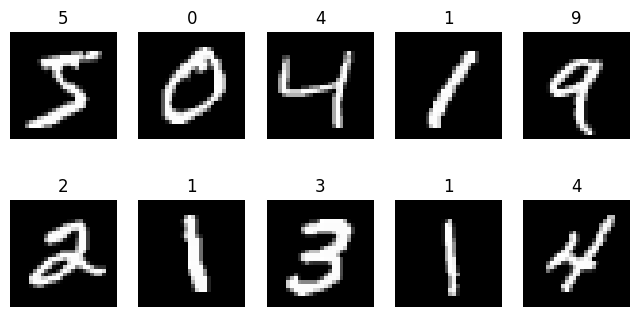

In [11]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [12]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),   
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-06-09 17:44:59.708464: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9193 - loss: 0.2760 - val_accuracy: 0.9580 - val_loss: 0.1388
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9656 - loss: 0.1140 - val_accuracy: 0.9667 - val_loss: 0.1083
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9751 - loss: 0.0801 - val_accuracy: 0.9715 - val_loss: 0.0991
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0584 - val_accuracy: 0.9756 - val_loss: 0.0820
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9856 - loss: 0.0457 - val_accuracy: 0.9707 - val_loss: 0.0997
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9887 - loss: 0.0359 - val_accuracy: 0.9732 - val_loss: 0.1014
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9903 - loss: 0.0298 - val_accuracy: 0.9748 - val_loss: 0.0939
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9913 - loss: 0.0250 - 

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9762 - loss: 0.1005
Test Accuracy: 0.9761999845504761


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


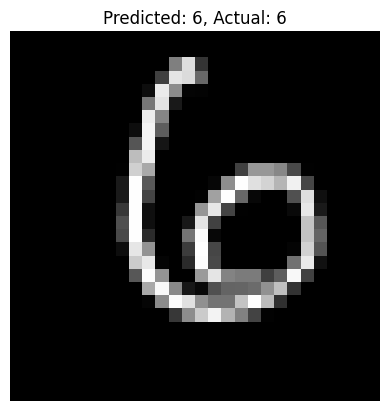

In [16]:
predictions = model.predict(x_test)

# show one example
index = 100

plt.imshow(x_test[index], cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[index])}, Actual: {y_test[index]}")
plt.axis('off')
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [18]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [19]:
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

[[ 970    0    1    0    2    0    2    1    4    0]
 [   0 1125    2    2    0    0    2    0    4    0]
 [   2    1  998    7    5    0    1   11    7    0]
 [   0    0    3  992    0    1    0    5    6    3]
 [   4    0    1    1  964    0    5    2    0    5]
 [   3    0    0   19    2  847    5    1   11    4]
 [   2    2    1    2    7    1  942    0    1    0]
 [   1    1    7    1    2    0    0 1014    1    1]
 [   3    0    1    9    3    1    3    6  945    3]
 [   3    3    0    1   21    0    1   13    2  965]]


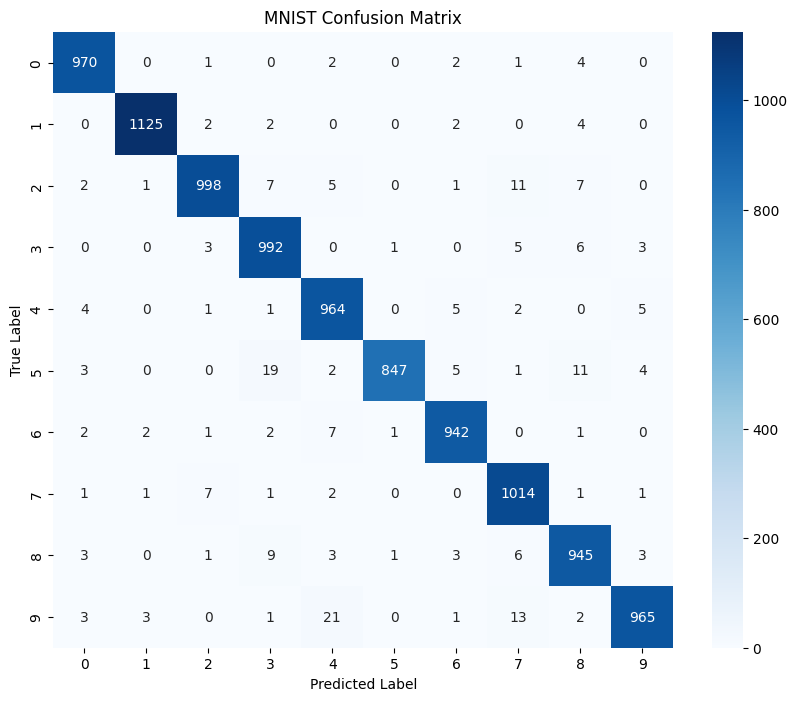

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

In [21]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.96      0.98      0.97       982
           5       1.00      0.95      0.97       892
           6       0.98      0.98      0.98       958
           7       0.96      0.99      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

